# 04 · Model Training

**Input:** `gold_train.parquet`, `gold_test.parquet`  
**Output:** `models/best_model.pkl`, diagnostic PDFs, `reports/model_comparison.csv`  
**Models:** Logistic Regression, GradientBoostingClassifier (±Elo)  
**Split:** chronological — no future data leaks into training

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import joblib
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              roc_auc_score, brier_score_loss, roc_curve, auc)
from sklearn.calibration import calibration_curve
import warnings; warnings.filterwarnings('ignore')

GOLD_DIR   = Path('../data/gold')
MODEL_DIR  = Path('../models');   MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR    = Path('../figures');  FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = Path('../reports'); REPORT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42

# ── palette ──────────────────────────────────────────────────────────────────
PRIMARY, SECONDARY, GREY = '#075020', '#8A7A2F', '#888888'
bok_cmap = LinearSegmentedColormap.from_list('bok', [SECONDARY, PRIMARY])

# ── global rcParams — all figures same size, font, spine style ───────────────
sns.set_theme(style='whitegrid')
mpl.rcParams.update({
    'figure.figsize':    (10, 6),
    'figure.dpi':        120,
    'savefig.dpi':       300,
    'font.family':       'serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'legend.framealpha': 0.95,
})

def save_fig(name):
    plt.savefig(FIG_DIR / name, bbox_inches='tight', dpi=300)
    plt.show()
    print(f'Saved: {name}')


In [2]:
train = pd.read_parquet(GOLD_DIR / 'gold_train.parquet')
test  = pd.read_parquet(GOLD_DIR / 'gold_test.parquet')
y_tr, y_te = train.win.astype(int), test.win.astype(int)
print(f'Train: {len(train):,} (WR {y_tr.mean():.1%}) | Test: {len(test):,} (WR {y_te.mean():.1%})')
print(f'Teams — train: {train.team.nunique()} | test: {test.team.nunique()}')

Train: 2,918 (WR 49.1%) | Test: 492 (WR 48.4%)
Teams — train: 25 | test: 23


In [3]:
FEAT_NUM = [
    'home',
    'rolling_form_3', 'rolling_form_5', 'rolling_form_10', 'rolling_margin_3',
    'h2h_winrate',
    'consecutive_wins',
    'days_since_prev',
    'experience', 'experience_diff',
    'tournament_tier', 
    'rwc_appearances', 'rwc_best_stage', 'rwc_cumul_score',
    'elo_diff_pre',
]
FEAT_NUM_NO_ELO = [f for f in FEAT_NUM if f != 'elo_diff_pre']
FEAT_CAT        = ['team', 'opponent', 'tournament']

missing = [f for f in FEAT_NUM + FEAT_CAT if f not in train.columns]
assert not missing, f'Missing features: {missing}'
print(f'Features — numeric: {len(FEAT_NUM)} | categorical: {len(FEAT_CAT)}')

Features — numeric: 15 | categorical: 3


In [4]:
def make_pipe(feat_num, clf):
    pre = ColumnTransformer([
        ('num', StandardScaler(), feat_num),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEAT_CAT),
    ])
    return Pipeline([('pre', pre), ('clf', clf)])

def eval_pipe(pipe, X_tr, X_te):
    pipe.fit(X_tr, y_tr)
    prob = pipe.predict_proba(X_te)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return pipe, prob, {
        'acc':   accuracy_score(y_te, pred),
        'prec':  precision_score(y_te, pred, zero_division=0),
        'rec':   recall_score(y_te, pred, zero_division=0),
        'auc':   roc_auc_score(y_te, prob),
        'brier': brier_score_loss(y_te, prob),
    }

results = {}
for label, feat_num in [('no_elo', FEAT_NUM_NO_ELO), ('with_elo', FEAT_NUM)]:
    X_tr, X_te = train[feat_num+FEAT_CAT], test[feat_num+FEAT_CAT]
    lr_pipe,  lr_prob,  lr_m  = eval_pipe(
        make_pipe(feat_num, LogisticRegression(max_iter=1000, random_state=SEED)), X_tr, X_te)
    xgb_pipe, xgb_prob, xgb_m = eval_pipe(
        make_pipe(feat_num, GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED)), X_tr, X_te)
    results[label] = {'lr': (lr_pipe,lr_prob,lr_m), 'xgb': (xgb_pipe,xgb_prob,xgb_m)}
    print(f'{label:10s} | LR  acc={lr_m["acc"]:.3f} auc={lr_m["auc"]:.3f}'
          f' | GBT acc={xgb_m["acc"]:.3f} auc={xgb_m["auc"]:.3f}')

best_model = results['with_elo']['xgb'][0]
joblib.dump(best_model, MODEL_DIR / 'best_model.pkl')
print('\nSaved: best_model.pkl  (GBT + Elo + all features)')

no_elo     | LR  acc=0.724 auc=0.776 | GBT acc=0.724 auc=0.783


with_elo   | LR  acc=0.724 auc=0.789 | GBT acc=0.734 auc=0.796

Saved: best_model.pkl  (GBT + Elo + all features)


In [5]:
rows = []
for label, d in results.items():
    for model, (_,_,m) in d.items():
        rows.append({'config': f'{model}_{label}',
                     **{k.upper(): round(v,4) for k,v in m.items()}})
comparison = pd.DataFrame(rows)
comparison.to_csv(REPORT_DIR / 'model_comparison.csv', index=False)
print(comparison.to_string(index=False))

      config    ACC   PREC    REC    AUC  BRIER
   lr_no_elo 0.7236 0.7125 0.7185 0.7761 0.1996
  xgb_no_elo 0.7236 0.7476 0.6471 0.7830 0.1935
 lr_with_elo 0.7236 0.7090 0.7269 0.7893 0.1933
xgb_with_elo 0.7337 0.7488 0.6765 0.7958 0.1897


In [6]:
# ── walk-forward (time-series) cross-validation ───────────────────────────
# Standard k-fold CV is invalid for time-series data (look-ahead bias).
# Walk-forward validation trains on all data up to year Y,
# tests on year Y+1, then expands the window.
# Reference: Cerqueira et al. (2020). Evaluating time series forecasting
#   models: An empirical study on performance estimation methods.
#   Machine Learning, 109, 1997–2028.

WF_FOLDS = [
    ('1995-01-01', '2015-12-31', '2016-01-01', '2016-12-31'),
    ('1995-01-01', '2016-12-31', '2017-01-01', '2017-12-31'),
    ('1995-01-01', '2017-12-31', '2018-01-01', '2018-12-31'),
    ('1995-01-01', '2018-12-31', '2019-01-01', '2019-12-31'),
]

full_data = pd.concat([train, test]).sort_values('date').reset_index(drop=True)

print('Walk-forward cross-validation (expanding window):')
print(f'{"Fold":<8} {"Train":>6} {"Test":>5} {"AUC LR":>8} {"AUC GBT":>9} {"AUC Elo":>9}')
wf_rows = []

for tr_start, tr_end, te_start, te_end in WF_FOLDS:
    tr = full_data[(full_data.date >= tr_start) & (full_data.date <= tr_end)]
    te = full_data[(full_data.date >= te_start) & (full_data.date <= te_end)]
    if len(te) < 20:
        continue

    y_tr_f = tr.win.astype(int)
    y_te_f = te.win.astype(int)
    X_tr_f = tr[FEAT_NUM + FEAT_CAT]
    X_te_f = te[FEAT_NUM + FEAT_CAT]

    lr_f  = make_pipe(FEAT_NUM, LogisticRegression(max_iter=1000, random_state=SEED))
    gbt_f = make_pipe(FEAT_NUM, GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED))
    lr_f.fit(X_tr_f, y_tr_f)
    gbt_f.fit(X_tr_f, y_tr_f)

    auc_lr  = roc_auc_score(y_te_f, lr_f.predict_proba(X_te_f)[:,1])
    auc_gbt = roc_auc_score(y_te_f, gbt_f.predict_proba(X_te_f)[:,1])
    auc_elo = roc_auc_score(y_te_f, 1/(1+10**(-te['elo_diff_pre']/400)))

    fold = te_start[:4]
    wf_rows.append(dict(fold=fold, n_train=len(tr), n_test=len(te),
                        auc_lr=auc_lr, auc_gbt=auc_gbt, auc_elo=auc_elo))
    print(f'{fold:<8} {len(tr):>6} {len(te):>5} {auc_lr:>8.3f} {auc_gbt:>9.3f} {auc_elo:>9.3f}')

wf_df = pd.DataFrame(wf_rows)
print(f'\nMean — LR: {wf_df.auc_lr.mean():.3f} | '
      f'GBT: {wf_df.auc_gbt.mean():.3f} | '
      f'Elo: {wf_df.auc_elo.mean():.3f}')
wf_df.to_csv(REPORT_DIR / 'walk_forward_cv.csv', index=False)
print('Saved: walk_forward_cv.csv')


Walk-forward cross-validation (expanding window):
Fold      Train  Test   AUC LR   AUC GBT   AUC Elo


2016       2312   112    0.837     0.827     0.834


2017       2424    98    0.905     0.907     0.871


2018       2522   112    0.798     0.815     0.816


2019       2634   156    0.910     0.888     0.842

Mean — LR: 0.862 | GBT: 0.860 | Elo: 0.841
Saved: walk_forward_cv.csv


In [7]:
# ── Elo baseline model ────────────────────────────────────────────────────
# Pure Elo prediction as a reference baseline.
# If ML models don't beat Elo, the features add no value.
# Reference: Hvattum & Arntzen (2010) — Elo as sports forecasting baseline.

def elo_prob(elo_diff):
    """Win probability from Elo differential."""
    return 1 / (1 + 10**(-elo_diff / 400))

elo_preds = elo_prob(test['elo_diff_pre'])
auc_elo   = roc_auc_score(y_te, elo_preds)
acc_elo   = ((elo_preds >= 0.5).astype(int) == y_te).mean()
brier_elo = brier_score_loss(y_te, elo_preds)

print('Elo baseline (reference):')
print(f'  AUC:    {auc_elo:.3f}')
print(f'  Acc:    {acc_elo:.3f}')
print(f'  Brier:  {brier_elo:.3f}')
print()
print('Model comparison vs Elo baseline:')
for label, d in results.items():
    for model, (_,_,m) in d.items():
        delta = m["auc"] - auc_elo
        sign  = '+' if delta >= 0 else ''
        print(f'  {model}_{label:<15} AUC={m["auc"]:.3f}  '
              f'Δ vs Elo: {sign}{delta:.3f}')


Elo baseline (reference):
  AUC:    0.765
  Acc:    0.691
  Brier:  0.199

Model comparison vs Elo baseline:
  lr_no_elo          AUC=0.776  Δ vs Elo: +0.011
  xgb_no_elo          AUC=0.783  Δ vs Elo: +0.018
  lr_with_elo        AUC=0.789  Δ vs Elo: +0.025
  xgb_with_elo        AUC=0.796  Δ vs Elo: +0.031


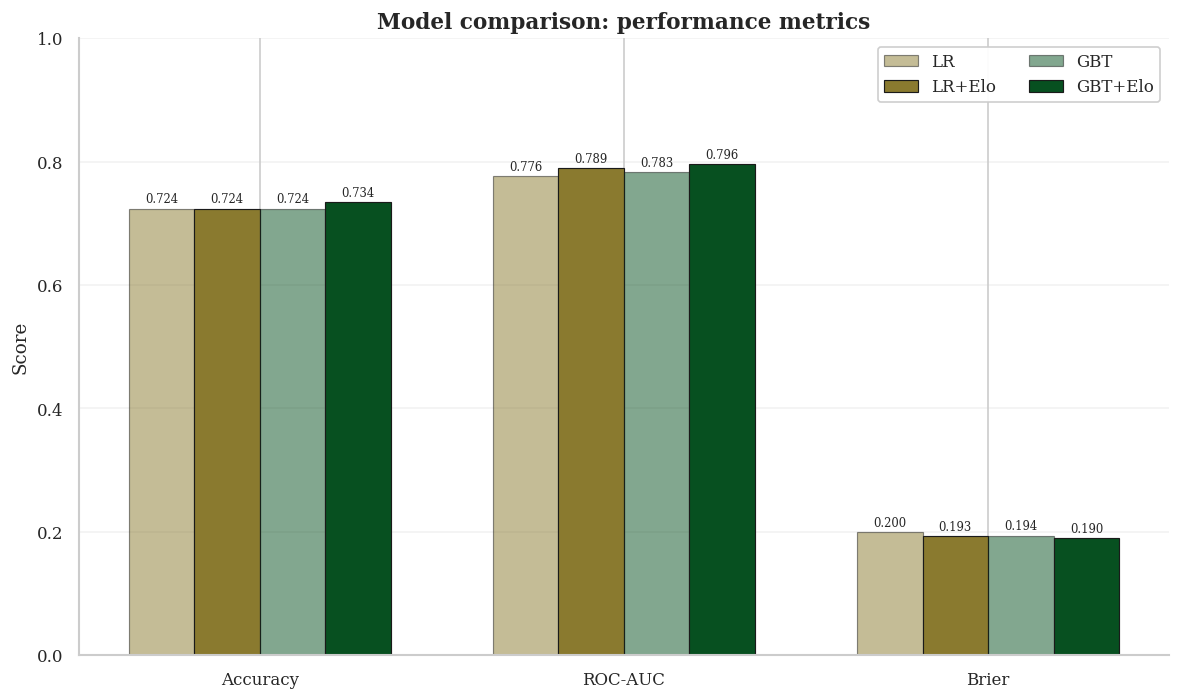

Saved: model_comparison.pdf


In [8]:
metrics = [('acc','Accuracy'),('auc','ROC-AUC'),('brier','Brier')]
configs  = [
    ('LR',      SECONDARY, 0.5, results['no_elo']['lr'][2]),
    ('LR+Elo',  SECONDARY, 1.0, results['with_elo']['lr'][2]),
    ('GBT',     PRIMARY,   0.5, results['no_elo']['xgb'][2]),
    ('GBT+Elo', PRIMARY,   1.0, results['with_elo']['xgb'][2]),
]
x, w = np.arange(len(metrics)), 0.18
fig, ax = plt.subplots()
for i, (lbl, col, alpha, m) in enumerate(configs):
    vals = [m[k] for k,_ in metrics]
    bars = ax.bar(x+(i-1.5)*w, vals, w, label=lbl,
                  color=col, alpha=alpha, edgecolor='k', lw=0.7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', fontsize=7)
ax.set(title='Model comparison: performance metrics', ylabel='Score', ylim=(0,1))
ax.set_xticks(x); ax.set_xticklabels([n for _,n in metrics])
ax.legend(ncol=2); ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout(); save_fig('model_comparison.pdf')

Computing bootstrap CIs (n=1000)...
  LR: AUC=0.776


  GBT: AUC=0.783
  LR+Elo: AUC=0.789


  GBT+Elo: AUC=0.796


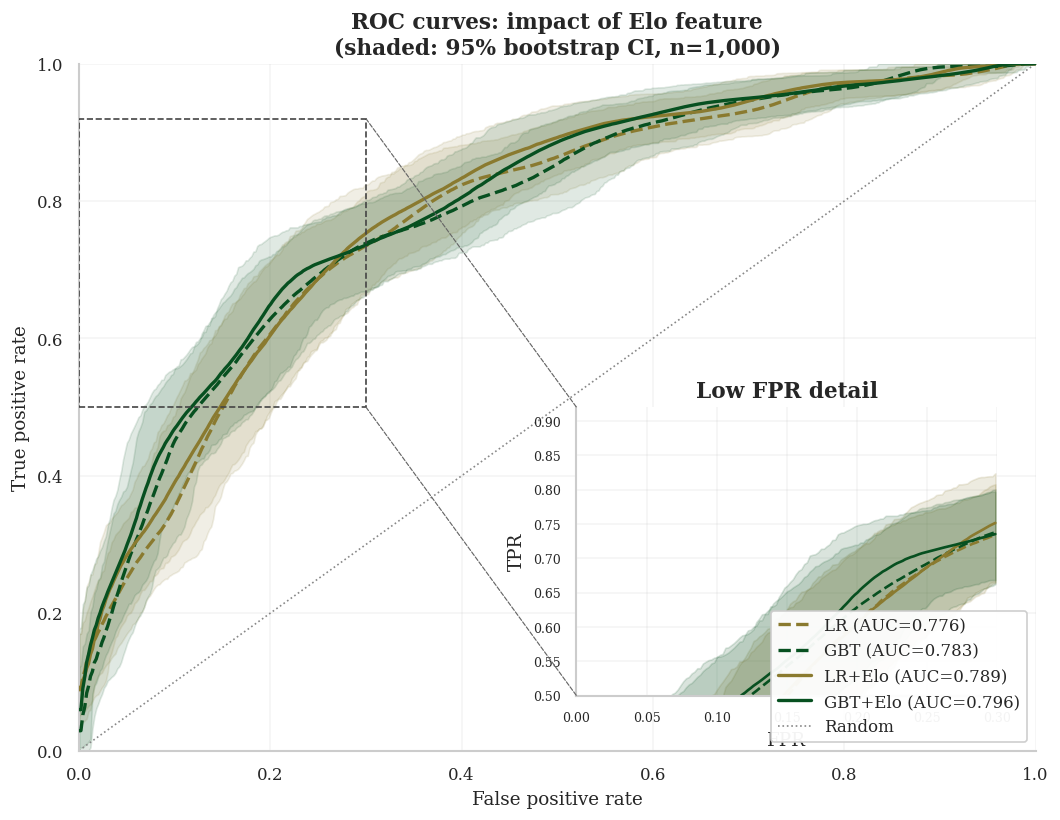

Saved: model_roc_curves.pdf


In [9]:
FPR_GRID = np.linspace(0, 1, 500)
rng      = np.random.default_rng(SEED)

def bootstrap_roc(y_true, y_score, n=1000):
    tprs = []
    for _ in range(n):
        idx = rng.integers(0, len(y_true), len(y_true))
        yt, ys = np.array(y_true)[idx], np.array(y_score)[idx]
        if len(np.unique(yt)) < 2: continue
        fpr_b, tpr_b, _ = roc_curve(yt, ys)
        tprs.append(np.interp(FPR_GRID, fpr_b, tpr_b))
    t = np.array(tprs)
    return t.mean(0), np.quantile(t,0.025,0), np.quantile(t,0.975,0)

curve_specs = [
    ('LR',      SECONDARY,'--',results['no_elo']['lr'][1]),
    ('GBT',     PRIMARY,  '--',results['no_elo']['xgb'][1]),
    ('LR+Elo',  SECONDARY,'-', results['with_elo']['lr'][1]),
    ('GBT+Elo', PRIMARY,  '-', results['with_elo']['xgb'][1]),
]
curves = []
print('Computing bootstrap CIs (n=1000)...')
for lbl, col, ls, prob in curve_specs:
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc_val      = auc(fpr, tpr)
    mean, lo, hi = bootstrap_roc(y_te, prob)
    curves.append((lbl, col, ls, auc_val, mean, lo, hi))
    print(f'  {lbl}: AUC={auc_val:.3f}')

fig, ax = plt.subplots(figsize=(9, 7))
for lbl, col, ls, auc_val, mean, lo, hi in curves:
    ax.plot(FPR_GRID, mean, color=col, lw=2, ls=ls, zorder=3,
            label=f'{lbl} (AUC={auc_val:.3f})')
    ax.fill_between(FPR_GRID, lo, hi, color=col, alpha=0.12, zorder=2)
ax.plot([0,1],[0,1], color=GREY, lw=1, ls=':', label='Random')
ax.set(xlim=(0,1), ylim=(0,1),
       xlabel='False positive rate', ylabel='True positive rate',
       title='ROC curves: impact of Elo feature\n'
             '(shaded: 95% bootstrap CI, n=1,000)')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.2)

# zoom inset
IX1,IX2,IY1,IY2 = 0.0,0.3,0.5,0.92
ax_in = ax.inset_axes([0.52,0.08,0.44,0.42])
mask  = (FPR_GRID>=IX1)&(FPR_GRID<=IX2)
for lbl,col,ls,_,mean,lo,hi in curves:
    ax_in.plot(FPR_GRID[mask], mean[mask], color=col, lw=1.6, ls=ls)
    ax_in.fill_between(FPR_GRID[mask], lo[mask], hi[mask], color=col, alpha=0.15)
ax_in.set(xlim=(IX1,IX2), ylim=(IY1,IY2),
          title='Low FPR detail', xlabel='FPR', ylabel='TPR')
ax_in.tick_params(labelsize=7.5); ax_in.grid(True, alpha=0.2)
ax_in.spines[['top','right']].set_visible(False)
rect = mpatches.FancyBboxPatch((IX1,IY1),IX2-IX1,IY2-IY1,
       boxstyle='square,pad=0', lw=1, ec='#444', fc='none', ls='--', zorder=4)
ax.add_patch(rect)
for mxy,ixy in [((IX2,IY1),(0,0)),((IX2,IY2),(0,1))]:
    fig.add_artist(ConnectionPatch(
        xyA=mxy, coordsA=ax.transData,
        xyB=ixy, coordsB=ax_in.transAxes,
        color='#666', lw=0.7, ls='--'))
plt.tight_layout(); save_fig('model_roc_curves.pdf')

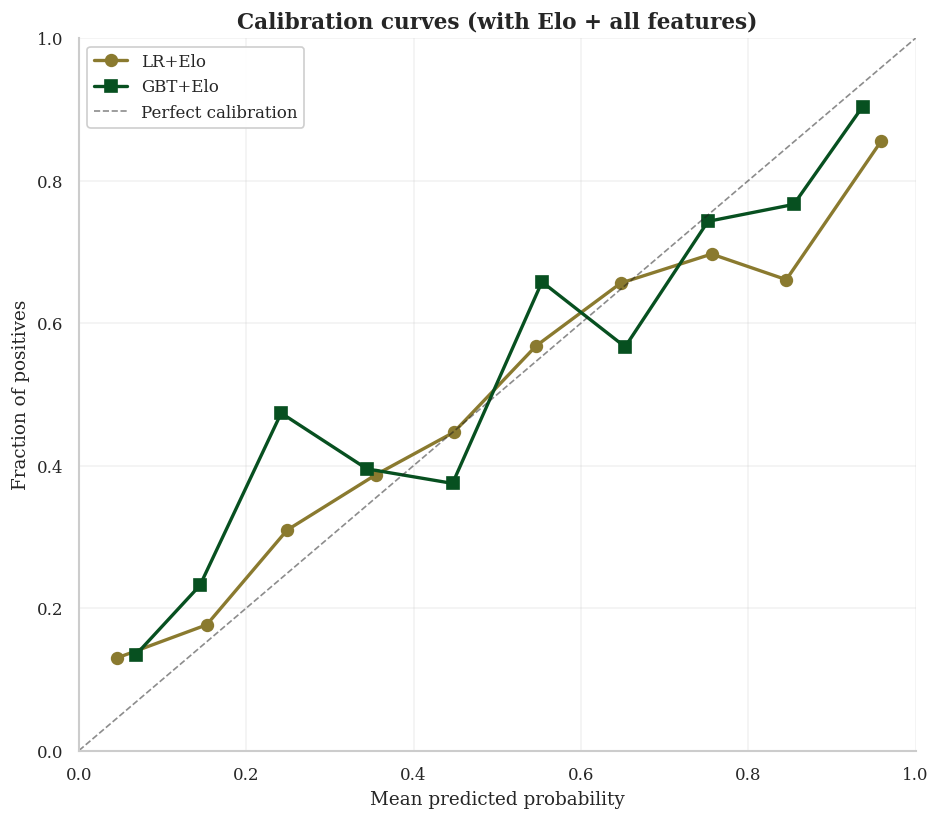

Saved: model_calibration.pdf


In [10]:
fig, ax = plt.subplots(figsize=(8, 7))
for lbl, col, marker, prob in [
    ('LR+Elo',  SECONDARY, 'o', results['with_elo']['lr'][1]),
    ('GBT+Elo', PRIMARY,   's', results['with_elo']['xgb'][1]),
]:
    pt, pp = calibration_curve(y_te, prob, n_bins=10, strategy='uniform')
    ax.plot(pp, pt, marker=marker, ms=7, color=col, lw=2, label=lbl)
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Perfect calibration')
ax.set(title='Calibration curves (with Elo + all features)',
       xlabel='Mean predicted probability', ylabel='Fraction of positives',
       xlim=(0,1), ylim=(0,1))
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout(); save_fig('model_calibration.pdf')

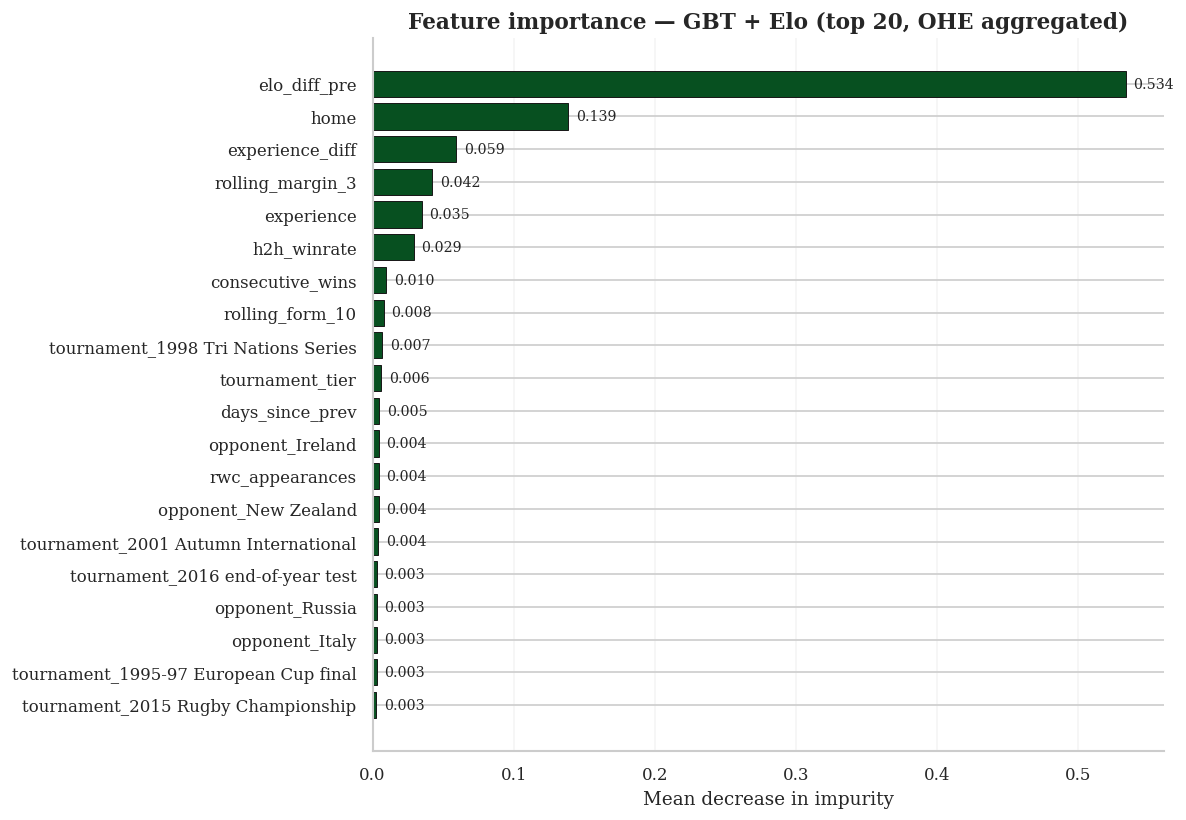

Saved: model_feature_importance.pdf


In [11]:
pipe = results['with_elo']['xgb'][0]
clf  = pipe.named_steps['clf']
pre  = pipe.named_steps['pre']

num_names = FEAT_NUM
cat_names = list(pre.named_transformers_['cat'].get_feature_names_out(FEAT_CAT))
imp = pd.Series(clf.feature_importances_, index=num_names + cat_names)

# aggregate OHE back to parent feature (e.g. 'tournament_x0_Six Nations' → 'tournament')
agg = {}
for name, v in imp.items():
    # OHE features look like: 'team_x0_South Africa', 'tournament_x0_Rugby World Cup'
    parent = name.split('_x0_')[0] if '_x0_' in name else name
    agg[parent] = agg.get(parent, 0) + v
imp_agg = pd.Series(agg).sort_values(ascending=True)

# keep only top 20 features for readability
imp_plot = imp_agg.tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PRIMARY if v > imp_agg.median() else SECONDARY for v in imp_plot]
bars   = ax.barh(imp_plot.index, imp_plot.values,
                 color=colors, edgecolor='k', lw=0.6)
for bar, v in zip(bars, imp_plot.values):
    ax.text(v + imp_plot.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=8.5)
ax.set(title='Feature importance — GBT + Elo (top 20, OHE aggregated)',
       xlabel='Mean decrease in impurity')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout(); save_fig('model_feature_importance.pdf')
